# Fictalent · Auditoria de qualidade · comercial, a carteira que gera receita
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar a carteira: clientes, contratos e seus aditivos, os postos contratados, a tabela de preço por posto, os SLAs acordados e as ocorrências. É daqui que sai a receita e a margem por posto; defeito aqui vira número errado no faturamento e na pergunta que ninguém sabe responder, a margem por cliente.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `comercial`: `cliente`, `cliente_contato`, `contrato`, `contrato_aditivo`, `posto`, `posto_preco`, `sla_contrato`, `contrato_ocorrencia`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Chaves, domínios e referências da DDL estão cumpridos na bronze?
2. O status do contrato bate com as datas dele (assinatura, vigência, encerramento, motivo)?
3. Todo posto vigente tem preço vigente, sem período descoberto nem dois preços ao mesmo tempo?
4. O CNPJ dos clientes é válido, e o cadastro está livre de cliente duplicado por grafia?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [Texto](#secao-7)
8. [Vigências e ordem temporal](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("comercial")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("comercial")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

8 tabelas do domínio: cliente, cliente_contato, contrato, contrato_aditivo, posto, posto_preco, sla_contrato, contrato_ocorrencia


## Nota Técnica

**Observado:** mesma configuração do notebook anterior: pandas, DuckDB e matplotlib, o lake aberto pelo pacote do projeto, as 8 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina; roda em qualquer estação com o `.env` preenchido.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 4.486


,tabela,linhas_vivas,marca
0,comercial.cliente,100,2026-09-24 15:02:06.227515
1,comercial.cliente_contato,181,2026-09-24 15:02:06.227515
2,comercial.contrato,128,2026-09-24 15:02:06.227515
3,comercial.contrato_aditivo,514,2026-09-24 15:02:06.227515
4,comercial.posto,694,2026-09-24 15:02:06.227515
5,comercial.posto_preco,1248,2026-09-24 15:02:06.227515
6,comercial.sla_contrato,300,2026-09-24 15:02:06.227515
7,comercial.contrato_ocorrencia,1321,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 4.486 linhas vivas em 8 tabelas: 100 clientes, 128 contratos com 514 aditivos, 694 postos com 1.248 preços, 300 SLAs e 1.321 ocorrências. A carga acompanha a réplica até a marca d'água impressa acima.

**Por que importa:** é a carteira inteira de 2018 até a data de referência; os números do fechamento descrevem esta carga e devem ser relidos a cada carga nova.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

85 colunas em 8 tabelas
Colunas com um valor só: 0
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,comercial.cliente,id,BIGINT,0,0.00,96,1,100
1,comercial.cliente,razao_social,VARCHAR,0,0.00,113,Babovale Alimentos Ltda,Zudupasul Logística Ltda
2,comercial.cliente,nome_fantasia,VARCHAR,0,0.00,105,Babovale,Zudupasul
3,comercial.cliente,cnpj,VARCHAR,0,0.00,100,11946737000118,99270001000113
4,comercial.cliente,porte,VARCHAR,0,0.00,4,EPP,MEDIA
5,comercial.cliente,setor,VARCHAR,0,0.00,5,AGRO,VAREJO
6,comercial.cliente,municipio_id,BIGINT,0,0.00,39,4,111
7,comercial.cliente,endereco_id,BIGINT,0,0.00,116,4,163
8,comercial.cliente,dt_primeiro_contrato,DATE,0,0.00,97,2018-01-05,2026-07-31
9,comercial.cliente,origem,VARCHAR,0,0.00,5,INDICACAO,SITE


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

85 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 85 colunas, nenhuma constante e nenhuma totalmente vazia; os tipos da bronze compatíveis com a DDL em todas (a checagem de tipo foi acrescentada depois do defeito de ingestão encontrado no cadastro). As datas cobrem 2018 a 2027 (`vigencia_fim` de contratos vigentes), e os valores de preço vão de R$ 3.319 a R$ 12.114 mensais por posto.

**Por que importa:** o perfil é o mapa: aqui ele aponta para as vigências (seção 8) e para a coerência entre status e datas (seções 4 e 10), que é onde um cadastro comercial costuma envelhecer.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude

As colunas `NOT NULL` da DDL não podem ter nulo na bronze. Nas que aceitam nulo, há três casos: vazio legítimo (contrato por prazo indeterminado não tem `vigencia_fim`; contrato ativo não tem `dt_encerramento`), vazio por regra (aditivo de reajuste não tem `vigencia_nova`) e vazio por falha. Só o terceiro é achado, e ele é testado pela coerência com outra coluna.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 8; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
45,comercial.contrato_aditivo,percentual_reajuste,"DECIMAL(7,4)",351,68.29,False
44,comercial.contrato_aditivo,vigencia_nova,DATE,277,53.89,False
78,comercial.contrato_ocorrencia,posto_id,BIGINT,577,43.68,False
36,comercial.contrato,motivo_encerramento_id,BIGINT,52,40.62,False
35,comercial.contrato,dt_encerramento,DATE,52,40.62,False
56,comercial.posto,vigencia_fim,DATE,150,21.61,False
65,comercial.posto_preco,vigencia_fim,DATE,150,12.02,False
82,comercial.contrato_ocorrencia,motivo_id,BIGINT,55,4.16,False


In [7]:
# os nulos são coerentes com o que outra coluna diz?
coerencia = consulta.sql(con, '''
    SELECT 'contrato ENCERRADO sem dt_encerramento' AS caso, count(*) AS linhas FROM comercial.contrato WHERE excluido_em IS NULL AND status = 'ENCERRADO' AND dt_encerramento IS NULL
    UNION ALL SELECT 'contrato ENCERRADO sem motivo_encerramento', count(*) FROM comercial.contrato WHERE excluido_em IS NULL AND status = 'ENCERRADO' AND motivo_encerramento_id IS NULL
    UNION ALL SELECT 'contrato nao encerrado com dt_encerramento', count(*) FROM comercial.contrato WHERE excluido_em IS NULL AND status <> 'ENCERRADO' AND dt_encerramento IS NOT NULL
    UNION ALL SELECT 'contrato nao encerrado com motivo_encerramento', count(*) FROM comercial.contrato WHERE excluido_em IS NULL AND status <> 'ENCERRADO' AND motivo_encerramento_id IS NOT NULL
    UNION ALL SELECT 'aditivo PRORROGACAO sem vigencia_nova', count(*) FROM comercial.contrato_aditivo WHERE excluido_em IS NULL AND tipo = 'PRORROGACAO' AND vigencia_nova IS NULL
    UNION ALL SELECT 'aditivo REAJUSTE sem percentual', count(*) FROM comercial.contrato_aditivo WHERE excluido_em IS NULL AND tipo = 'REAJUSTE' AND percentual_reajuste IS NULL
    UNION ALL SELECT 'aditivo nao REAJUSTE com percentual', count(*) FROM comercial.contrato_aditivo WHERE excluido_em IS NULL AND tipo <> 'REAJUSTE' AND percentual_reajuste IS NOT NULL
    UNION ALL SELECT 'cliente sem endereco', count(*) FROM comercial.cliente WHERE excluido_em IS NULL AND endereco_id IS NULL
    UNION ALL SELECT 'cliente sem dt_primeiro_contrato mas com contrato', count(*) FROM comercial.cliente c WHERE c.excluido_em IS NULL AND c.dt_primeiro_contrato IS NULL AND EXISTS (SELECT 1 FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.cliente_id = c.id)
    UNION ALL SELECT 'cliente sem nenhum contrato', count(*) FROM comercial.cliente c WHERE c.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.cliente_id = c.id)
    UNION ALL SELECT 'cliente sem contato principal', count(*) FROM comercial.cliente c WHERE c.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM comercial.cliente_contato x WHERE x.excluido_em IS NULL AND x.cliente_id = c.id AND x.fl_principal)
    UNION ALL SELECT 'ocorrencia RECLAMACAO sem descricao', count(*) FROM comercial.contrato_ocorrencia WHERE excluido_em IS NULL AND tipo = 'RECLAMACAO' AND descricao IS NULL
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))

Testes de coerência: 12; com linhas: 0
                                             caso  linhas
           contrato ENCERRADO sem dt_encerramento       0
       contrato ENCERRADO sem motivo_encerramento       0
       contrato nao encerrado com dt_encerramento       0
   contrato nao encerrado com motivo_encerramento       0
            aditivo PRORROGACAO sem vigencia_nova       0
                  aditivo REAJUSTE sem percentual       0
              aditivo nao REAJUSTE com percentual       0
                             cliente sem endereco       0
cliente sem dt_primeiro_contrato mas com contrato       0
                      cliente sem nenhum contrato       0
                    cliente sem contato principal       0
              ocorrencia RECLAMACAO sem descricao       0


## Nota Técnica

**Observado:** oito colunas com nulo, nenhuma `NOT NULL`. Os doze testes de coerência entre o nulo e a coluna que o explica passaram todos: contrato encerrado sempre tem data e motivo de encerramento, contrato vigente nunca tem; aditivo de prorrogação sempre tem a nova vigência e aditivo de reajuste sempre tem o percentual; todo cliente tem endereço, contato principal e ao menos um contrato, e a data do primeiro contrato bate com o primeiro contrato.

**Por que importa:** nulo coerente é o que permite usar a coluna como regra (`dt_encerramento IS NULL` significa vigente) sem tratar exceção. O sistema de origem preenche esses campos em conjunto, e a bronze mostra isso.

**Ação:** nenhuma.

<a id="secao-5"></a>

# 5. Unicidade

As chaves `UNIQUE` da DDL (CNPJ, número do contrato, aditivo por contrato, indicador de SLA por contrato) e a duplicidade de conteúdo: o mesmo cliente com dois CNPJs por grafia da razão social, o mesmo contato duas vezes, o mesmo posto aberto duas vezes no mesmo contrato.

In [8]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
unicas

4 chaves UNIQUE conferidas; com repetição: 0


,tabela,chave,grupos_repetidos,linhas
0,comercial.cliente,cnpj,0,0
1,comercial.contrato,numero,0,0
2,comercial.contrato_aditivo,"contrato_id, numero",0,0
3,comercial.sla_contrato,"contrato_id, indicador",0,0


In [9]:
conteudo = {
    ("comercial.cliente", ("razao_social",)): "a mesma razão social em dois cadastros",
    ("comercial.cliente", ("nome_fantasia",)): "o mesmo nome fantasia em dois cadastros",
    ("comercial.cliente_contato", ("cliente_id", "nome")): "o mesmo contato duas vezes no mesmo cliente",
    ("comercial.cliente_contato", ("email",)): "o mesmo e-mail em dois contatos",
    ("comercial.posto", ("contrato_id", "funcao_id", "turno", "endereco_id", "vigencia_inicio")): "o mesmo posto aberto duas vezes",
    ("comercial.posto_preco", ("posto_id", "vigencia_inicio")): "dois preços começando no mesmo dia para o mesmo posto",
}
resultado = {}
for (tabela, colunas), descricao in conteudo.items():
    grupos, envolvidas = checagens.repetidos(con, tabela, list(colunas), normalizar=True)
    resultado[(tabela, colunas)] = (grupos, envolvidas)
    print(f"{tabela:<26} {'+'.join(colunas):<58} {grupos:>4} grupos  {envolvidas:>5} linhas   ({descricao})")

comercial.cliente          razao_social                                                  0 grupos      0 linhas   (a mesma razão social em dois cadastros)
comercial.cliente          nome_fantasia                                                 0 grupos      0 linhas   (o mesmo nome fantasia em dois cadastros)
comercial.cliente_contato  cliente_id+nome                                               0 grupos      0 linhas   (o mesmo contato duas vezes no mesmo cliente)
comercial.cliente_contato  email                                                         0 grupos      0 linhas   (o mesmo e-mail em dois contatos)
comercial.posto            contrato_id+funcao_id+turno+endereco_id+vigencia_inicio       4 grupos      8 linhas   (o mesmo posto aberto duas vezes)
comercial.posto_preco      posto_id+vigencia_inicio                                      0 grupos      0 linhas   (dois preços começando no mesmo dia para o mesmo posto)


In [10]:
chave_posto = ["contrato_id", "funcao_id", "turno", "endereco_id", "vigencia_inicio"]
pares = consulta.sql(con, '''
    SELECT p.id, p.contrato_id, p.funcao_id, p.turno, p.escala_id, p.quantidade, p.vigencia_inicio, p.vigencia_fim
    FROM comercial.posto p
    WHERE p.excluido_em IS NULL AND (p.contrato_id, p.funcao_id, p.turno, p.endereco_id, p.vigencia_inicio) IN (
      SELECT contrato_id, funcao_id, turno, endereco_id, vigencia_inicio FROM comercial.posto WHERE excluido_em IS NULL
      GROUP BY 1, 2, 3, 4, 5 HAVING count(*) > 1)
    ORDER BY p.contrato_id, p.funcao_id, p.turno, p.vigencia_inicio, p.id''')
grupos_posto, linhas_posto = resultado[("comercial.posto", tuple(chave_posto))]
n_postos = checagens.linhas(con, "comercial.posto")
registro.anotar(
    secao="5", tabela="comercial.posto", coluna=", ".join(chave_posto),
    achado="postos idênticos em contrato, função, turno, endereço e início, diferindo só em quantidade, escala ou fim", linhas=linhas_posto, total=n_postos, severidade="baixa",
    impacto="pode ser desdobramento legítimo (dois lotes de vagas) ou o mesmo posto cadastrado duas vezes; no segundo caso as vagas contam em dobro no headcount contratado",
    acao="confirmar com o comercial; na silver, marcar o par, nunca fundir",
)
n_clientes = checagens.linhas(con, "comercial.cliente")
registro.anotar(
    secao="5", tabela="comercial.cliente", coluna="razao_social, nome_fantasia, cnpj",
    achado="hipótese refutada: não há cliente duplicado por grafia nem CNPJ repetido", linhas=resultado[("comercial.cliente", ("razao_social",))][1], total=n_clientes, severidade="nenhuma",
    impacto="não há conformação de cliente a fazer", acao="nenhuma",
)
pares

,id,contrato_id,funcao_id,turno,escala_id,quantidade,vigencia_inicio,vigencia_fim
0,16,10,25,COMERCIAL,2,20,2018-05-14,2022-02-02
1,17,10,25,COMERCIAL,2,8,2018-05-14,2020-04-15
2,150,44,1,TARDE,1,9,2021-12-17,2022-01-12
3,153,44,1,TARDE,4,1,2021-12-17,2022-01-17
4,250,62,34,COMERCIAL,1,4,2023-01-25,2023-12-11
5,252,62,34,COMERCIAL,1,2,2023-01-25,2026-01-24
6,316,78,2,TARDE,3,12,2023-10-26,2023-12-28
7,318,78,2,TARDE,2,5,2023-10-26,2023-12-15


## Nota Técnica

**Observado:** as 4 chaves `UNIQUE` (CNPJ, número do contrato, aditivo por contrato, indicador de SLA por contrato) estão íntegras, e não há cliente nem contato duplicado por grafia. A duplicidade de conteúdo aparece em `posto`: 4 pares de postos (8 linhas de 694) idênticos em contrato, função, turno, endereço e data de início, diferindo em quantidade, escala ou data de fim.

**Por que importa:** a tabela de posto não tem chave natural na DDL, e o par idêntico pode ser um desdobramento legítimo (dois lotes de vagas para o mesmo posto, com fins diferentes) ou o mesmo posto cadastrado duas vezes. Se for o segundo, as vagas contam em dobro no headcount contratado e o preço se aplica duas vezes.

**Ação:** anotar como achado de severidade baixa: confirmar com o comercial; na silver, marcar, nunca fundir (a autoridade sobre o cadastro é do cliente).

<a id="secao-6"></a>

# 6. Domínios declarados

Toda coluna com `CHECK (... IN (...))` na DDL, conferida na bronze, e a distribuição dentro de cada domínio, que o `CHECK` não vê.

In [11]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
dominios

8 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,comercial.cliente,porte,5,0,
1,comercial.cliente,origem,5,0,
2,comercial.contrato,tipo_servico,4,0,
3,comercial.contrato,status,3,0,
4,comercial.contrato_aditivo,tipo,3,0,
5,comercial.posto,turno,5,0,
6,comercial.sla_contrato,indicador,3,0,
7,comercial.contrato_ocorrencia,tipo,4,0,


In [12]:
# a distribuição dentro do domínio também informa: categoria com uma linha só costuma ser erro de digitação que passou pelo CHECK
for tabela, coluna in (("comercial.cliente", "porte"), ("comercial.cliente", "setor"), ("comercial.cliente", "origem"), ("comercial.contrato", "tipo_servico"), ("comercial.contrato", "status"), ("comercial.contrato_aditivo", "tipo"), ("comercial.posto", "turno"), ("comercial.contrato_ocorrencia", "tipo")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT {coluna}, count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))

comercial.cliente.porte: EPP=38, MEDIA=36, ME=19, GRANDE=7


comercial.cliente.setor: INDUSTRIA=32, VAREJO=28, LOGISTICA=23, SERVICOS=13, AGRO=4
comercial.cliente.origem: INDICACAO=48, PROSPECCAO=33, SITE=16, RETORNO=2, LICITACAO=1
comercial.contrato.tipo_servico: TEMPORARIO=49, RECRUTAMENTO=42, TERCEIRIZACAO=37
comercial.contrato.status: ENCERRADO=76, ATIVO=52
comercial.contrato_aditivo.tipo: PRORROGACAO=237, REAJUSTE=163, ESCOPO=114
comercial.posto.turno: COMERCIAL=219, TARDE=215, MANHA=122, NOITE=117, REVEZAMENTO=21
comercial.contrato_ocorrencia.tipo: RECLAMACAO=1052, ELOGIO=186, AVISO_RESCISAO=55, ADVERTENCIA=28


## Nota Técnica

**Observado:** os 8 domínios declarados só têm valores previstos, e a distribuição dentro de cada um faz sentido para o negócio: 49 contratos temporários, 42 de recrutamento e 37 de terceirização; 52 ativos e 76 encerrados; ocorrências dominadas por reclamações (1.052 de 1.321), com 55 avisos de rescisão.

**Por que importa:** a distribuição é a leitura que o `CHECK` não faz: categoria com uma linha só costuma ser erro de digitação que passou pela restrição. Aqui as menores categorias (1 licitação, 2 retornos) são plausíveis como origem de cliente.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. Texto

Razão social, nome fantasia, nome do contato, descrição de ocorrência: o texto digitado. Aqui ele vira rótulo de painel e chave de conciliação com o financeiro.

In [13]:
campos = [("comercial.cliente", "razao_social"), ("comercial.cliente", "nome_fantasia"), ("comercial.cliente_contato", "nome"), ("comercial.cliente_contato", "email"), ("comercial.cliente_contato", "cargo"), ("comercial.contrato_ocorrencia", "descricao")]
vicios = pd.DataFrame([{"campo": f"{t}.{c}", **checagens.texto_inconsistente(con, t, c)} for t, c in campos]).set_index("campo")
email_ruim = checagens.contar(con, "SELECT count(*) FROM comercial.cliente_contato WHERE excluido_em IS NULL AND email IS NOT NULL AND NOT regexp_matches(email, '^[^@\\s]+@[^@\\s]+\\.[^@\\s]+$')")
print(f"e-mails fora do formato: {email_ruim}")
vicios

e-mails fora do formato: 0


,espacos_nas_pontas,espacos_duplos,caixa_alta,caixa_baixa,valores_com_mais_de_uma_grafia,linhas_em_grafia_multipla
campo,,,,,,
comercial.cliente.razao_social,0,0,0,0,0,0
comercial.cliente.nome_fantasia,0,0,0,0,0,0
comercial.cliente_contato.nome,0,0,0,0,0,0
comercial.cliente_contato.email,0,0,0,181,0,0
comercial.cliente_contato.cargo,0,0,0,0,0,0
comercial.contrato_ocorrencia.descricao,0,0,0,0,0,0


## Nota Técnica

**Observado:** razão social, nome fantasia, nome, cargo e e-mail dos contatos e descrição das ocorrências sem espaço sobrando, sem caixa alta e sem grafia múltipla; todos os 181 e-mails válidos no formato. Os 181 e-mails aparecem como "caixa baixa" na métrica, e isso é convenção de e-mail, não vício.

**Por que importa:** a métrica de caixa serve para nome de pessoa e de empresa; em e-mail ela acusa o que é correto. Fica dito para o leitor não contar isso como defeito.

**Ação:** nenhuma.

<a id="secao-8"></a>

# 8. Vigências e ordem temporal

Assinatura antes da vigência, vigência antes do fim, encerramento dentro da vigência, aditivo depois do contrato, posto dentro do contrato, preço dentro do posto. E os dois defeitos de vigência: períodos que se cruzam e períodos descobertos.

In [14]:
ordem = [
    ("comercial.contrato", "dt_assinatura", "vigencia_inicio"),
    ("comercial.contrato", "vigencia_inicio", "vigencia_fim"),
    ("comercial.contrato", "vigencia_inicio", "dt_encerramento"),
    ("comercial.posto", "vigencia_inicio", "vigencia_fim"),
    ("comercial.posto_preco", "vigencia_inicio", "vigencia_fim"),
]
for tabela, antes, depois in ordem:
    print(f"{tabela:<26} {depois} < {antes}: {checagens.ordem_temporal(con, tabela, antes, depois)}")
print(f"comercial.posto_preco: períodos cruzados no mesmo posto: {checagens.sobreposicoes(con, 'comercial.posto_preco', 'posto_id', 'vigencia_inicio', 'vigencia_fim')}")

comercial.contrato         vigencia_inicio < dt_assinatura: 0
comercial.contrato         vigencia_fim < vigencia_inicio: 0
comercial.contrato         dt_encerramento < vigencia_inicio: 0
comercial.posto            vigencia_fim < vigencia_inicio: 0
comercial.posto_preco      vigencia_fim < vigencia_inicio: 0
comercial.posto_preco: períodos cruzados no mesmo posto: 0


In [15]:
entre_tabelas = consulta.sql(con, '''
    SELECT 'aditivo assinado antes do contrato' AS caso, count(*) AS linhas
      FROM comercial.contrato_aditivo a JOIN comercial.contrato k ON k.id = a.contrato_id
     WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND a.dt_assinatura < k.dt_assinatura
    UNION ALL SELECT 'aditivo assinado depois do encerramento', count(*)
      FROM comercial.contrato_aditivo a JOIN comercial.contrato k ON k.id = a.contrato_id
     WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND k.dt_encerramento IS NOT NULL AND a.dt_assinatura > k.dt_encerramento
    UNION ALL SELECT 'posto comeca antes da vigencia do contrato', count(*)
      FROM comercial.posto p JOIN comercial.contrato k ON k.id = p.contrato_id
     WHERE p.excluido_em IS NULL AND k.excluido_em IS NULL AND p.vigencia_inicio < k.vigencia_inicio
    UNION ALL SELECT 'posto termina depois do encerramento do contrato', count(*)
      FROM comercial.posto p JOIN comercial.contrato k ON k.id = p.contrato_id
     WHERE p.excluido_em IS NULL AND k.excluido_em IS NULL AND k.dt_encerramento IS NOT NULL AND coalesce(p.vigencia_fim, DATE '9999-12-31') > k.dt_encerramento
    UNION ALL SELECT 'preco comeca antes do posto', count(*)
      FROM comercial.posto_preco r JOIN comercial.posto p ON p.id = r.posto_id
     WHERE r.excluido_em IS NULL AND p.excluido_em IS NULL AND r.vigencia_inicio < p.vigencia_inicio
    UNION ALL SELECT 'ocorrencia fora da vigencia do contrato', count(*)
      FROM comercial.contrato_ocorrencia o JOIN comercial.contrato k ON k.id = o.contrato_id
     WHERE o.excluido_em IS NULL AND k.excluido_em IS NULL AND (o.dt_ocorrencia < k.vigencia_inicio OR o.dt_ocorrencia > coalesce(k.dt_encerramento, k.vigencia_fim, DATE '9999-12-31'))
''')
print(entre_tabelas.to_string(index=False))
fora = consulta.sql(con, '''
    SELECT o.id, o.contrato_id, o.dt_ocorrencia, o.tipo, k.vigencia_inicio, k.vigencia_fim, k.dt_encerramento, k.status
    FROM comercial.contrato_ocorrencia o JOIN comercial.contrato k ON k.id = o.contrato_id
    WHERE o.excluido_em IS NULL AND (o.dt_ocorrencia < k.vigencia_inicio OR o.dt_ocorrencia > coalesce(k.dt_encerramento, k.vigencia_fim, DATE '9999-12-31'))''')
fora

                                            caso  linhas
              aditivo assinado antes do contrato       0
         aditivo assinado depois do encerramento       0
      posto comeca antes da vigencia do contrato       0
posto termina depois do encerramento do contrato       0
                     preco comeca antes do posto       0
         ocorrencia fora da vigencia do contrato       1


,id,contrato_id,dt_ocorrencia,tipo,vigencia_inicio,vigencia_fim,dt_encerramento,status
0,1262,36,2026-07-27,RECLAMACAO,2021-01-13,2027-01-12,2026-07-25,ENCERRADO


In [16]:
# posto descoberto: posto vigente sem preço vigente, medido no 1º de cada mês do arco
descobertos = consulta.sql(con, '''
    WITH meses AS (SELECT unnest(generate_series(DATE '2018-01-01', ?::DATE, INTERVAL 1 MONTH))::DATE AS dia),
         vigentes AS (
           SELECT p.id AS posto_id, m.dia FROM comercial.posto p JOIN meses m ON m.dia BETWEEN p.vigencia_inicio AND coalesce(p.vigencia_fim, DATE '9999-12-31')
           WHERE p.excluido_em IS NULL)
    SELECT count(*) AS posto_mes_vigente,
           count(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM comercial.posto_preco r WHERE r.excluido_em IS NULL AND r.posto_id = v.posto_id AND v.dia BETWEEN r.vigencia_inicio AND coalesce(r.vigencia_fim, DATE '9999-12-31'))) AS sem_preco
    FROM vigentes v''', HOJE)
print(descobertos.to_string(index=False))
n_ocorrencias = checagens.linhas(con, "comercial.contrato_ocorrencia")
registro.anotar(
    secao="8", tabela="comercial.contrato_ocorrencia", coluna="dt_ocorrencia",
    achado="ocorrência lançada fora da vigência do contrato (depois do encerramento)", linhas=len(fora), total=n_ocorrencias, severidade="baixa",
    impacto="indicador de SLA por contrato vigente perde a ocorrência ou a atribui a um período sem receita",
    acao="manter e marcar na silver como ocorrência pós-encerramento",
)

 posto_mes_vigente  sem_preco
              8693          0


Achado(dominio='comercial', secao='8', tabela='comercial.contrato_ocorrencia', coluna='dt_ocorrencia', achado='ocorrência lançada fora da vigência do contrato (depois do encerramento)', linhas=1, total=1321, severidade='baixa', impacto='indicador de SLA por contrato vigente perde a ocorrência ou a atribui a um período sem receita', acao='manter e marcar na silver como ocorrência pós-encerramento', declaracao='')

## Nota Técnica

**Observado:** nenhuma inversão de data em contrato, posto e preço; nenhum preço cruzado no mesmo posto; nenhum posto vigente sem preço vigente em 8.693 posto-meses conferidos; aditivo sempre depois do contrato e nunca depois do encerramento; posto sempre dentro do contrato. Uma única exceção: a reclamação 1262, lançada em 27/07/2026 no contrato 36, encerrado em 25/07/2026.

**Por que importa:** vigência íntegra é o que permite calcular receita por competência com um join só. A reclamação dois dias após o encerramento é plausível como reclamação tardia, mas cai fora da vigência e qualquer indicador de SLA por contrato vigente a perderia ou a atribuiria a um período sem receita.

**Ação:** anotar como achado de severidade baixa: manter e marcar na silver como ocorrência pós-encerramento.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL, conferida na bronze; mãe marcada como excluída conta como ausente.

In [17]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

17 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,comercial.cliente,municipio_id,cadastro.municipio,0
1,comercial.cliente,endereco_id,cadastro.endereco,0
2,comercial.cliente_contato,cliente_id,comercial.cliente,0
3,comercial.contrato,cliente_id,comercial.cliente,0
4,comercial.contrato,filial_id,cadastro.filial,0
5,comercial.contrato,centro_custo_id,cadastro.centro_custo,0
6,comercial.contrato,motivo_encerramento_id,cadastro.motivo,0
7,comercial.contrato_aditivo,contrato_id,comercial.contrato,0
8,comercial.posto,contrato_id,comercial.contrato,0
9,comercial.posto,funcao_id,cadastro.funcao,0


## Nota Técnica

**Observado:** as 17 chaves estrangeiras do domínio (para cadastro e dentro do comercial) sem nenhum órfão.

**Por que importa:** toda junção de contrato com cliente, filial, centro de custo, função, escala e endereço é segura; o comercial pode ser lido com a régua do cadastro sem perder linha.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio

O que a DDL não declara e o negócio exige: CNPJ válido, o status do contrato coerente com as datas e com o cliente, quantidade e preço positivos, markup e penalidade em faixa plausível, e o retrato da carteira (postos por tipo de serviço, contratos ativos hoje, preço por ano).

In [18]:
cnpj_linhas, cnpj_distintos = checagens.documentos_invalidos(con, "comercial.cliente", "cnpj", checagens.cnpj_valido)
print(f"CNPJ inválido pelo dígito verificador: {cnpj_linhas} clientes")
regras = consulta.sql(con, '''
    SELECT 'contrato ATIVO com vigencia_fim vencida e sem prorrogacao' AS caso, count(*) AS linhas
      FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.status = 'ATIVO' AND k.vigencia_fim < ?
       AND NOT EXISTS (SELECT 1 FROM comercial.contrato_aditivo a WHERE a.excluido_em IS NULL AND a.contrato_id = k.id AND a.tipo = 'PRORROGACAO' AND coalesce(a.vigencia_nova, DATE '1900-01-01') >= ?)
    UNION ALL SELECT 'cliente inativo com contrato ATIVO', count(DISTINCT c.id)
      FROM comercial.cliente c JOIN comercial.contrato k ON k.cliente_id = c.id
     WHERE c.excluido_em IS NULL AND k.excluido_em IS NULL AND NOT c.ativo AND k.status = 'ATIVO'
    UNION ALL SELECT 'cliente ativo sem nenhum contrato ATIVO', count(*)
      FROM comercial.cliente c WHERE c.excluido_em IS NULL AND c.ativo
       AND NOT EXISTS (SELECT 1 FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.cliente_id = c.id AND k.status = 'ATIVO')
    UNION ALL SELECT 'dt_primeiro_contrato diferente do primeiro contrato', count(*)
      FROM comercial.cliente c JOIN (SELECT cliente_id, min(vigencia_inicio) AS primeira FROM comercial.contrato WHERE excluido_em IS NULL GROUP BY 1) k ON k.cliente_id = c.id
     WHERE c.excluido_em IS NULL AND c.dt_primeiro_contrato IS NOT NULL AND c.dt_primeiro_contrato <> k.primeira
    UNION ALL SELECT 'posto com quantidade <= 0', count(*) FROM comercial.posto WHERE excluido_em IS NULL AND quantidade <= 0
    UNION ALL SELECT 'preco com valor_mensal <= 0', count(*) FROM comercial.posto_preco WHERE excluido_em IS NULL AND valor_mensal <= 0
    UNION ALL SELECT 'preco com valor_hora < 0', count(*) FROM comercial.posto_preco WHERE excluido_em IS NULL AND valor_hora < 0
    UNION ALL SELECT 'markup fora de 0..2 (0% a 200%)', count(*) FROM comercial.posto_preco WHERE excluido_em IS NULL AND (markup_aplicado < 0 OR markup_aplicado > 2)
    UNION ALL SELECT 'SLA com penalidade fora de 0..100', count(*) FROM comercial.sla_contrato WHERE excluido_em IS NULL AND (penalidade_pct < 0 OR penalidade_pct > 100)
    UNION ALL SELECT 'SLA com meta <= 0', count(*) FROM comercial.sla_contrato WHERE excluido_em IS NULL AND meta_valor <= 0
    UNION ALL SELECT 'contrato de RECRUTAMENTO ou TREINAMENTO com posto', count(DISTINCT k.id)
      FROM comercial.contrato k JOIN comercial.posto p ON p.contrato_id = k.id
     WHERE k.excluido_em IS NULL AND p.excluido_em IS NULL AND k.tipo_servico IN ('RECRUTAMENTO', 'TREINAMENTO')
    UNION ALL SELECT 'contrato TEMPORARIO ou TERCEIRIZACAO sem nenhum posto', count(*)
      FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.tipo_servico IN ('TEMPORARIO', 'TERCEIRIZACAO')
       AND NOT EXISTS (SELECT 1 FROM comercial.posto p WHERE p.excluido_em IS NULL AND p.contrato_id = k.id)
    UNION ALL SELECT 'prazo_pagamento fora de 0..120 dias', count(*) FROM comercial.contrato WHERE excluido_em IS NULL AND (prazo_pagamento_dias < 0 OR prazo_pagamento_dias > 120)
''', HOJE, HOJE)
print(f"Regras conferidas: {len(regras)}; com linhas: {int((regras['linhas'] > 0).sum())}")
print(regras.to_string(index=False))

CNPJ inválido pelo dígito verificador: 0 clientes


Regras conferidas: 13; com linhas: 1
                                                     caso  linhas
contrato ATIVO com vigencia_fim vencida e sem prorrogacao       1
                       cliente inativo com contrato ATIVO       0
                  cliente ativo sem nenhum contrato ATIVO       0
      dt_primeiro_contrato diferente do primeiro contrato       0
                                posto com quantidade <= 0       0
                              preco com valor_mensal <= 0       0
                                 preco com valor_hora < 0       0
                          markup fora de 0..2 (0% a 200%)       0
                        SLA com penalidade fora de 0..100       0
                                        SLA com meta <= 0       0
        contrato de RECRUTAMENTO ou TREINAMENTO com posto       0
    contrato TEMPORARIO ou TERCEIRIZACAO sem nenhum posto       0
                      prazo_pagamento fora de 0..120 dias       0


In [19]:
vencidos = consulta.sql(con, '''
    SELECT k.id, k.numero, k.tipo_servico, k.vigencia_inicio, k.vigencia_fim, k.status,
           (SELECT max(vigencia_nova) FROM comercial.contrato_aditivo a WHERE a.excluido_em IS NULL AND a.contrato_id = k.id AND a.tipo = 'PRORROGACAO') AS ultima_prorrogacao,
           (SELECT count(*) FROM comercial.posto p WHERE p.excluido_em IS NULL AND p.contrato_id = k.id AND p.vigencia_fim IS NULL) AS postos_abertos
    FROM comercial.contrato k WHERE k.excluido_em IS NULL AND k.status = 'ATIVO' AND k.vigencia_fim < ?
      AND NOT EXISTS (SELECT 1 FROM comercial.contrato_aditivo a WHERE a.excluido_em IS NULL AND a.contrato_id = k.id AND a.tipo = 'PRORROGACAO' AND coalesce(a.vigencia_nova, DATE '1900-01-01') >= ?)''', HOJE, HOJE)
n_contratos = checagens.linhas(con, "comercial.contrato")
registro.anotar(
    secao="10", tabela="comercial.contrato", coluna="status, vigencia_fim",
    achado="contrato ATIVO com vigência vencida e sem prorrogação que a cubra", linhas=len(vencidos), total=n_contratos, severidade="media",
    impacto="o status não acompanha a vigência: o cliente conta como ativo, o SLA segue em cobrança e a carteira aparece maior em qualquer relatório por status",
    acao="na silver, derivar a situação do contrato das datas (vigente, vencido, encerrado) e preservar o status original marcado; sugerir ao cliente o encerramento ou a prorrogação",
)
vencidos

,id,numero,tipo_servico,vigencia_inicio,vigencia_fim,status,ultima_prorrogacao,postos_abertos
0,108,CT-2024-0025,RECRUTAMENTO,2024-09-19,2026-09-18,ATIVO,2026-09-18,0


In [20]:
retrato = consulta.sql(con, '''
    SELECT k.tipo_servico, k.status, count(DISTINCT k.id) AS contratos, count(DISTINCT p.id) AS postos, coalesce(sum(p.quantidade), 0) AS vagas
    FROM comercial.contrato k LEFT JOIN comercial.posto p ON p.contrato_id = k.id AND p.excluido_em IS NULL
    WHERE k.excluido_em IS NULL GROUP BY 1, 2 ORDER BY 1, 2''')
print(retrato.to_string(index=False))
print()
print(consulta.sql(con, "SELECT year(vigencia_inicio) AS ano, count(*) AS precos, min(valor_mensal) AS minimo, median(valor_mensal) AS mediana, max(valor_mensal) AS maximo, median(markup_aplicado) AS markup_mediano FROM comercial.posto_preco WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1").to_string(index=False))

 tipo_servico    status  contratos  postos    vagas
 RECRUTAMENTO     ATIVO         11       0     0.00
 RECRUTAMENTO ENCERRADO         31       0     0.00
   TEMPORARIO     ATIVO         25     209 1,594.00
   TEMPORARIO ENCERRADO         24     238 1,813.00
TERCEIRIZACAO     ATIVO         16     122   509.00
TERCEIRIZACAO ENCERRADO         21     125   633.00

 ano  precos   minimo  mediana    maximo  markup_mediano
2018      34 3,319.68 3,916.28  7,198.92            1.47
2019      67 3,427.17 4,070.30  6,947.20            1.50
2020      45 3,590.42 4,269.37  7,748.22            1.49
2021      71 3,780.12 4,353.35  7,838.84            1.51
2022     147 3,866.28 4,942.42  8,396.51            1.51
2023     202 4,190.26 5,213.33  9,524.28            1.51
2024     259 4,465.55 5,361.00  9,150.43            1.49
2025     242 4,688.07 5,656.15  9,656.58            1.50
2026     181 4,887.34 6,013.78 12,114.38            1.52


## Nota Técnica

**Observado:** os 100 CNPJs são válidos pelo dígito verificador. Das 13 regras de negócio, 12 passaram (cliente inativo com contrato ativo, quantidade e preço positivos, markup entre 0 e 200%, penalidade de SLA entre 0 e 100, contrato de recrutamento sem posto e de alocação com posto, prazo de pagamento até 120 dias). A que falhou: o contrato CT-2024-0025 (recrutamento) está `ATIVO` com vigência vencida em 18/09/2026, seis dias antes da data de referência, e a única prorrogação registrada termina nessa mesma data. O retrato da carteira: 52 contratos ativos (25 temporários, 16 terceirizações, 11 recrutamentos), 694 postos e 4.549 vagas contratadas no arco; preço mediano por posto de R$ 3.916 em 2018 para R$ 6.014 em 2026, com markup mediano estável em 1,5.

**Por que importa:** a DDL diz, no comentário de `contrato.status`, que o sistema guarda status e vigência e que a auditoria confere se batem: aqui não batem em um caso. Um contrato vencido que continua ativo conta o cliente como ativo, mantém o SLA em cobrança e infla a carteira em qualquer relatório por status. É um caso hoje; sem regra, vira um por semana.

**Ação:** anotar como achado de severidade média: a silver deriva a situação do contrato das datas (vigente, vencido, encerrado) e preserva o status original marcado, em vez de confiar no status.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [21]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        0
     media        1
     baixa        2
   nenhuma        1

Total: 4 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,media,10,comercial.contrato,"status, vigencia_fim",contrato ATIVO com vigência vencida e sem prorrogação que a cubra,1,128,0.78,
1,baixa,5,comercial.posto,"contrato_id, funcao_id, turno, endereco_id, vigencia_inicio","postos idênticos em contrato, função, turno, endereço e início, diferindo só em quantidade, esca...",8,694,1.15,
2,baixa,8,comercial.contrato_ocorrencia,dt_ocorrencia,ocorrência lançada fora da vigência do contrato (depois do encerramento),1,1321,0.08,
3,nenhuma,5,comercial.cliente,"razao_social, nome_fantasia, cnpj",hipótese refutada: não há cliente duplicado por grafia nem CNPJ repetido,0,100,0.00,


In [22]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,media,comercial.contrato,"status, vigencia_fim","o status não acompanha a vigência: o cliente conta como ativo, o SLA segue em cobrança e a carte...","na silver, derivar a situação do contrato das datas (vigente, vencido, encerrado) e preservar o ..."
1,baixa,comercial.posto,"contrato_id, funcao_id, turno, endereco_id, vigencia_inicio",pode ser desdobramento legítimo (dois lotes de vagas) ou o mesmo posto cadastrado duas vezes; no...,"confirmar com o comercial; na silver, marcar o par, nunca fundir"
2,baixa,comercial.contrato_ocorrencia,dt_ocorrencia,indicador de SLA por contrato vigente perde a ocorrência ou a atribui a um período sem receita,manter e marcar na silver como ocorrência pós-encerramento
3,nenhuma,comercial.cliente,"razao_social, nome_fantasia, cnpj",não há conformação de cliente a fazer,nenhuma


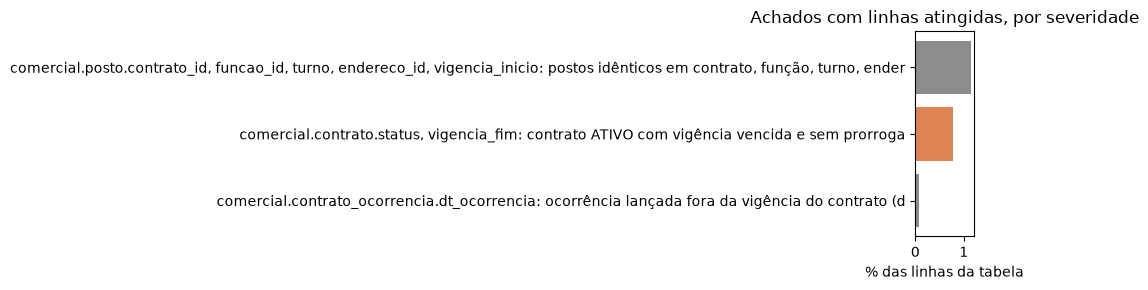

registro gravado em dados/auditoria/comercial.json


In [23]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 8 tabelas do domínio `comercial`, 85 colunas e 4.486 linhas vivas, na carga identificada na seção 2: tipo, completude com coerência entre colunas, unicidade por chave e por conteúdo, domínios e sua distribuição, texto, vigências dentro e entre tabelas, integridade referencial e as regras do negócio.

**O veredicto: a carteira é consistente, e os três achados são de borda.** Um contrato vencido há seis dias que continua `ATIVO` (média: o status não acompanha a vigência, e a regra da silver é derivar a situação das datas), quatro pares de postos idênticos que podem ser desdobramento ou duplicidade (baixa: confirmar, marcar, nunca fundir) e uma reclamação lançada dois dias depois do encerramento do contrato (baixa: marcar). CNPJ, chaves, referências, preços e vigências passaram inteiros; a hipótese de cliente duplicado por grafia foi refutada.

**Próximos passos:** o funil de colocação (`ats`), onde o cliente declarou candidatos duplicados e documentos inválidos; é o primeiro domínio com digitação diária, e o texto vai ser testado de verdade.